# 01 — Exploratory Data Analysis

Explores both datasets that feed into the multimodal fusion system:
the facial image dataset and the eye-tracking recordings.

## What this notebook does
- Analyses class distribution and image properties of the facial dataset
- Loads and inspects all 25 eye-tracking CSV files (57 participants)
- Engineers per-participant summary features from 1.3M raw gaze rows
- Compares ASD vs TD distributions across key gaze features
- Saves the engineered feature matrix for use in `03_eye_tracking.ipynb`

## Output
`eye_tracking_features.csv` — 57 × 38 feature matrix with class labels

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
import random
import warnings
import glob

warnings.filterwarnings('ignore')

In [63]:
# Mount drive and set paths - run at start of every session
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Paths
BASE_PATH = '/content/drive/MyDrive/Dataset'
FACE_PATH = f'{BASE_PATH}/autism_dataset/images'
EYE_PATH = f'{BASE_PATH}/eye_tracking_dataset/autism_eye_data/Eye-tracking Output'

print(f"Face data path exists: {os.path.exists(FACE_PATH)}")
print(f"Eye tracking path exists: {os.path.exists(EYE_PATH)}")

Face data path exists: True
Eye tracking path exists: True


## Face EDA

In [4]:
# Count images per split
for split in ['train', 'val', 'test']:
    split_path = f'{FACE_PATH}/{split}'
    images = [f for f in os.listdir(split_path) if f.endswith('.jpg')]
    labels = [f for f in os.listdir(split_path) if f.endswith('.txt')]
    print(f"{split}: {len(images)} images, {len(labels)} labels")

train: 2462 images, 2462 labels
val: 463 images, 463 labels
test: 473 images, 473 labels


In [ ]:
# Class distribution
def get_class_distribution(split):
    split_path = f'{FACE_PATH}/{split}'
    autistic, non_autistic = 0, 0
    for f in os.listdir(split_path):
        if f.endswith('.jpg'):
            if 'Autsim' in f and 'No_' not in f:
                autistic += 1
            else:
                non_autistic += 1
    return autistic, non_autistic

results = {}
for split in ['train', 'val', 'test']:
    a, n = get_class_distribution(split)
    results[split] = {'Autistic': a, 'Non-Autistic': n}
    print(f"{split} — Autistic: {a}, Non-Autistic: {n}, Total: {a+n}")



train — Autistic: 1312, Non-Autistic: 1150, Total: 2462
val — Autistic: 150, Non-Autistic: 313, Total: 463
test — Autistic: 160, Non-Autistic: 313, Total: 473


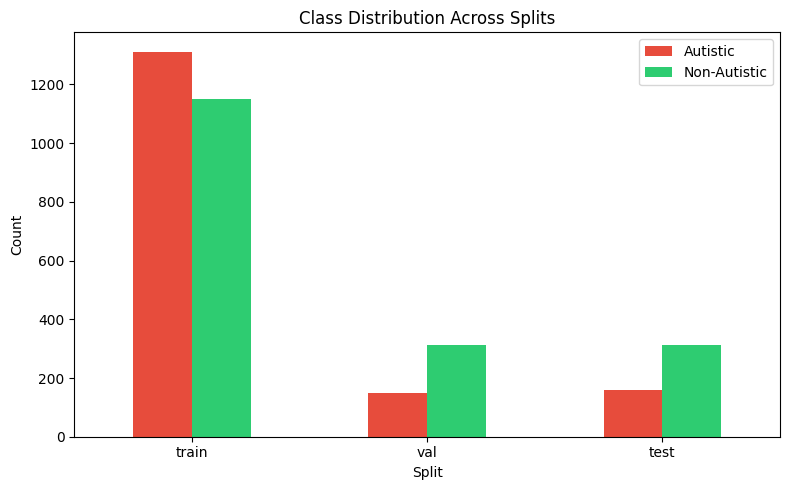

In [6]:
# Plot
df_dist = pd.DataFrame(results).T
df_dist.plot(kind='bar', figsize=(8,5), color=['#E74C3C', '#2ECC71'])
plt.title('Class Distribution Across Splits')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

- There is a class imbalance for val and test!

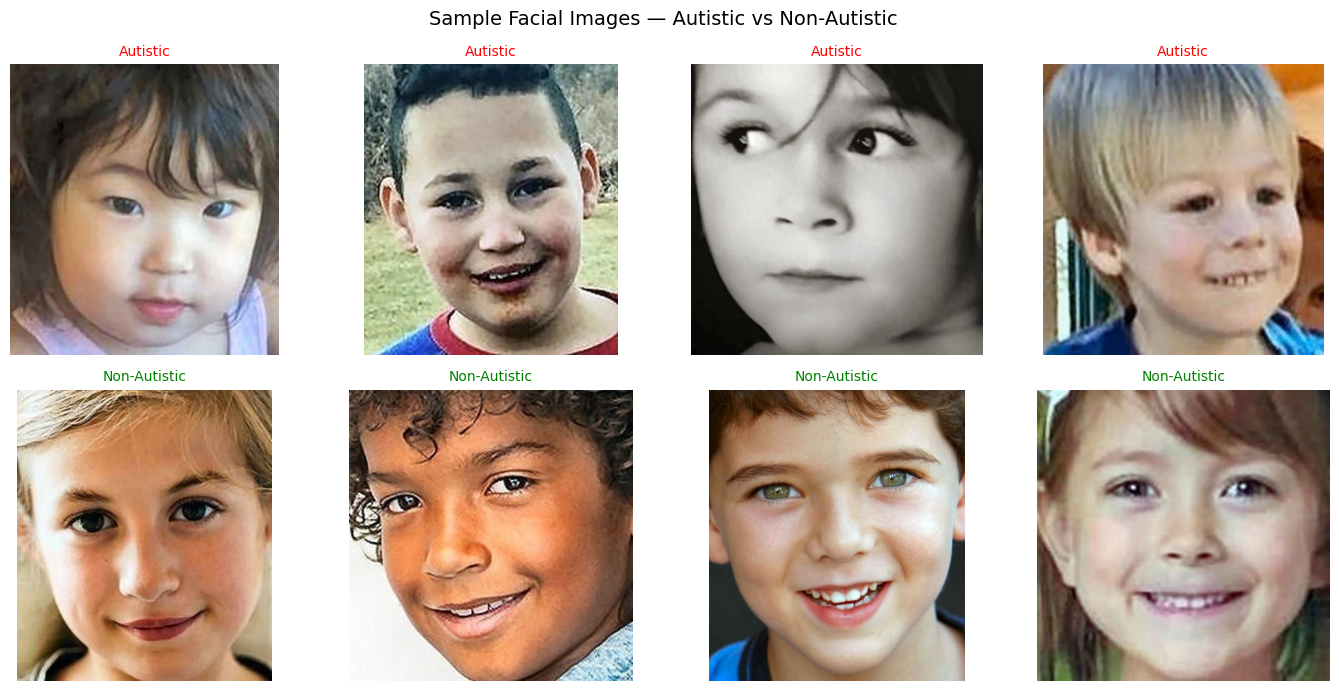

In [7]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Facial Images — Autistic vs Non-Autistic', fontsize=14)

autistic_imgs = [f for f in os.listdir(f'{FACE_PATH}/train') 
                 if f.endswith('.jpg') and 'No_' not in f][:4]
non_autistic_imgs = [f for f in os.listdir(f'{FACE_PATH}/train') 
                     if f.endswith('.jpg') and 'No_' in f][:4]

for i, img_name in enumerate(autistic_imgs):
    img = Image.open(f'{FACE_PATH}/train/{img_name}')
    axes[0, i].imshow(img)
    axes[0, i].set_title('Autistic', color='red', fontsize=10)
    axes[0, i].axis('off')

for i, img_name in enumerate(non_autistic_imgs):
    img = Image.open(f'{FACE_PATH}/train/{img_name}')
    axes[1, i].imshow(img)
    axes[1, i].set_title('Non-Autistic', color='green', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [10]:
# Sample 50 images to check dimensions and aspect ratios
sizes = []
all_imgs = []
for split in ['train', 'val', 'test']:
    for f in os.listdir(f'{FACE_PATH}/{split}'):
        if f.endswith('.jpg'):
            all_imgs.append(f'{FACE_PATH}/{split}/{f}')

for img_path in random.sample(all_imgs, 50):
    img = Image.open(img_path)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=['width', 'height'])
print(sizes_df.describe())
print(f"Most common size: {sizes_df.value_counts().index[0]}")

            width      height
count   50.000000   50.000000
mean   367.600000  412.180000
std     33.670068   15.812279
min    298.000000  320.000000
25%    338.250000  416.000000
50%    364.500000  416.000000
75%    401.250000  416.000000
max    416.000000  416.000000
Most common size: (np.int64(402), np.int64(416))


In [12]:
# Sample N label files to check class distribution
SAMPLE_SIZE = 50  # adjust as needed

class_counts = {0: 0, 1: 0, 2: 0}  # based on classes.txt
all_label_files = []

# Collect all label files first
for split in ['train', 'val', 'test']:
    split_path = f'{FACE_PATH}/{split}'
    for f in os.listdir(split_path):
        if f.endswith('.txt'):
            all_label_files.append(os.path.join(split_path, f))

# Randomly sample label files
sampled_files = random.sample(
    all_label_files,
    min(SAMPLE_SIZE, len(all_label_files))
)

# Count class labels from sampled files
for label_path in sampled_files:
    with open(label_path) as file:
        for line in file:
            cls = int(line.strip().split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

print(f"Class label distribution from {len(sampled_files)} sampled YOLO files:")
for cls, count in class_counts.items():
    print(f"  Class {cls}: {count} instances")

Class label distribution from 50 sampled YOLO files:
  Class 0: 24 instances
  Class 1: 72 instances
  Class 2: 26 instances


## EDA Summary — Facial Dataset

- Total images: 3,398 (train: 2,462 | val: 463 | test: 473)
- Image size: ~416x416px, consistent
- Classes: 0=autistic_face, 1=autism → merge to ASD; 2=no_autism → non-ASD
- Class imbalance: val/test skewed ~1:2 (autistic:non-autistic)
- Action: Apply weighted loss during training to handle imbalance

## Eye Tracking EDA

In [19]:
# Load all CSVs
eye_files = glob.glob(f'{EYE_PATH}/*.csv')

# Data overview
sample_df = pd.read_csv(eye_files[0])
print(f"\nSample file: {Path(eye_files[0]).name}")
print(f"Shape: {sample_df.shape}")
print(f"\nColumns ({len(sample_df.columns)}):")
print(sample_df.columns.tolist())


Sample file: 1.csv
Shape: (34630, 37)

Columns (37):
['Unnamed: 0', 'RecordingTime [ms]', 'Time of Day [h:m:s:ms]', 'Trial', 'Stimulus', 'Export Start Trial Time [ms]', 'Export End Trial Time [ms]', 'Participant', 'Color', 'Tracking Ratio [%]', 'Category Group', 'Category Right', 'Category Left', 'Index Right', 'Index Left', 'Pupil Diameter Right [mm]', 'Pupil Diameter Left [mm]', 'Point of Regard Right X [px]', 'Point of Regard Right Y [px]', 'Point of Regard Left X [px]', 'Point of Regard Left Y [px]', 'AOI Name Right', 'AOI Name Left', 'Gaze Vector Right X', 'Gaze Vector Right Y', 'Gaze Vector Right Z', 'Gaze Vector Left X', 'Gaze Vector Left Y', 'Gaze Vector Left Z', 'Annotation Name', 'Annotation Description', 'Annotation Tags', 'Mouse Position X [px]', 'Mouse Position Y [px]', 'Scroll Direction X', 'Scroll Direction Y', 'Content']


In [20]:
# Peek at one file
sample_df.head()

,Unnamed: 0,RecordingTime [ms],Time of Day [h:m:s:ms],Trial,Stimulus,Export Start Trial Time [ms],Export End Trial Time [ms],Participant,Color,Tracking Ratio [%],...,Gaze Vector Left Y,Gaze Vector Left Z,Annotation Name,Annotation Description,Annotation Tags,Mouse Position X [px],Mouse Position Y [px],Scroll Direction X,Scroll Direction Y,Content
0,0,4780015.315,13:22:17:254,Trial020,20 eye tracking (ballon droite).avi,0.0,52058.676,50,Coral,78.5652,...,-,-,-,-,-,-,-,-,-,eye tracking (ballon droite).avi
1,1,4780020.865,13:22:17:260,Trial020,20 eye tracking (ballon droite).avi,0.0,52058.676,50,Coral,78.5652,...,0.0000,0.0000,-,-,-,-,-,-,-,-
2,2,4780040.758,13:22:17:279,Trial020,20 eye tracking (ballon droite).avi,0.0,52058.676,50,Coral,78.5652,...,0.0000,0.0000,-,-,-,-,-,-,-,-
3,3,4780080.503,13:22:17:319,Trial020,20 eye tracking (ballon droite).avi,0.0,52058.676,50,Coral,78.5652,...,0.0000,0.0000,-,-,-,-,-,-,-,-
4,4,4780120.360,13:22:17:359,Trial020,20 eye tracking (ballon droite).avi,0.0,52058.676,50,Coral,78.5652,...,0.0000,0.0000,-,-,-,-,-,-,-,-


In [21]:
# Load all 25 CSVs into one dataframe, adding filename as participant reference
dfs = []
for f in sorted(glob.glob(f'{EYE_PATH}/*.csv')):
    df = pd.read_csv(f)
    df['file_id'] = Path(f).stem  # adds '1', '2', ... '25'
    dfs.append(df)

eye_df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {eye_df.shape[0]:,}")
print(f"Total columns: {eye_df.shape[1]}")
print(f"\nUnique participants (from 'Participant' col): {eye_df['Participant'].nunique()}")
print(f"Unique file IDs: {eye_df['file_id'].nunique()}")
print(f"\nRows per file:")
print(eye_df.groupby('file_id').size().sort_values())

Total rows: 2,252,943
Total columns: 60

Unique participants (from 'Participant' col): 97
Unique file IDs: 25

Rows per file:
file_id
2      16687
5      17769
13     21947
4      23136
14     28374
15     29699
1      34630
24     38663
10     51829
22     56929
7      61583
6      62648
18     70797
19     71234
12     73440
9      74479
16    110967
11    114285
8     114285
25    119064
20    123702
3     124658
23    130909
21    284931
17    396298
dtype: int64


In [22]:
# Checking for missing values
print("Missing values per column:")
missing = eye_df.isnull().sum()
missing_pct = (missing / len(eye_df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False))

Missing values per column:
                             missing_count  missing_%
groupe d'enfants                   2133879      94.72
AOI Group Left                     1378599      61.19
AOI Order Binocular                1377406      61.14
AOI Scope Left                     1377406      61.14
AOI Group Right                    1247103      55.35
AOI Order Right                    1241174      55.09
AOI Scope Right                    1241174      55.09
Pupil Size Left Y [px]             1210260      53.72
Pupil Size Left X [px]             1210260      53.72
Pupil Size Right Y [px]            1074028      47.67
Pupil Size Right X [px]            1074028      47.67
Pupil Diameter Left [mm]            950186      42.18
Port Status                         902292      40.05
Pupil Diameter Right [mm]           813954      36.13
Eye Position Left X [mm]            396306      17.59
Eye Position Left Z [mm]            396306      17.59
Pupil Position Left Y [px]          396306      17.59
E

In [23]:
# Check if there's any ASD label in the data
for col in ['Category Group', 'Category Right', 'Category Left', 'Color', 'Stimulus', 'Content']:
    print(f"\n--- {col} ---")
    print(eye_df[col].value_counts().head(10))


--- Category Group ---
Category Group
Eye            2247470
Information       5473
Name: count, dtype: int64

--- Category Right ---
Category Right
Fixation      1541507
Blink          374843
Saccade        196105
-              135015
Separator        5472
Left Click          1
Name: count, dtype: int64

--- Category Left ---
Category Left
Fixation      1437600
Blink          358347
Saccade        185779
-              129594
Separator        5390
Left Click          1
Name: count, dtype: int64

--- Color ---
Color
Cyan              178048
Crimson            65885
DarkKhaki          65810
DarkOrange         65809
DarkCyan           65078
DarkViolet         61537
Coral              60872
DarkTurquoise      59012
DarkBlue           58778
DarkOliveGreen     55156
Name: count, dtype: int64

--- Stimulus ---
Stimulus
VNVD151207.avi                          290153
NoImage                                 170019
Eye Tracking (ballon droite).avi        147596
Eye Tracking (ballon gauche).avi

In [24]:
# Understandint he metadata file
META_PATH = f'{BASE_PATH}/eye_tracking_dataset/autism_eye_data'
meta_files = glob.glob(f'{META_PATH}/*.csv')
print(f"Metadata file: {meta_files}")

Metadata file: ['/content/drive/MyDrive/Dataset/eye_tracking_dataset/autism_eye_data/Metadata_Participants.csv']


In [26]:
meta_df = pd.read_csv(meta_files[0])
print(f"Shape: {meta_df.shape}")
print(f"\nColumns: {meta_df.columns.tolist()}")

Shape: (59, 5)

Columns: ['ParticipantID', 'Gender', 'Age', 'Class', 'CARS Score']


In [27]:
meta_df.head(10)

,ParticipantID,Gender,Age,Class,CARS Score
0,1,M,7.0,ASD,32.5
1,2,F,8.9,ASD,36.5
2,3,M,4.4,ASD,27.0
3,4,M,6.9,ASD,35.0
4,5,M,8.9,ASD,31.0
5,6,M,4.7,ASD,27.0
6,7,M,9.3,ASD,34.5
7,8,F,12.3,ASD,34.5
8,9,M,2.7,ASD,27.0
9,10,M,9.5,ASD,26.5


In [42]:
# Check what participant IDs look like in eye tracking data
print("Eye tracking - sample Participant values:")
print(eye_df['Participant'].value_counts().head(20))

print(f"\nUnique participants in eye_df: {eye_df['Participant'].nunique()}")

# Check metadata participant IDs
print(f"\nMetadata ParticipantID sample:")
print(meta_df['ParticipantID'].tolist())

print(f"\nClass distribution in metadata:")
print(meta_df['Class'].value_counts())

Eye tracking - sample Participant values:
Participant
Unidentified(Neg)    878362
54                    76562
56                    51845
52                    43327
58                    42302
59                    41974
31                    41023
36                    38571
30                    36837
49                    33175
24                    30814
18                    28504
29                    28371
57                    27581
53                    26296
17                    26174
49                    25647
Unidentified(Pos)     23424
20                    19883
19                    19459
Name: count, dtype: int64

Unique participants in eye_df: 97

Metadata ParticipantID sample:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]

Class distribution in metadata:
Class
TD     30
ASD    29
Name: 

In [47]:
# How many numbered participants match metadata?
meta_ids = set(meta_df['ParticipantID'].astype(str))
eye_participants = eye_df['Participant'].astype(str).unique()

# Filter out Unidentified
real_eye_participants = set([p for p in eye_participants if 'Unidentified' not in str(p)])

print(f"Participants in metadata: {len(meta_ids)} → {sorted(meta_ids)}")
print(f"\nReal numbered participants in eye data: {len(real_eye_participants)} → {sorted(real_eye_participants, key=lambda x: int(x))}")
print(f"\nParticipants in BOTH (can be matched): {len(meta_ids & real_eye_participants)}")
print(f"In metadata but NOT in eye data: {meta_ids - real_eye_participants}")
print(f"In eye data but NOT in metadata: {real_eye_participants - meta_ids}")

Participants in metadata: 59 → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '7', '8', '9']

Real numbered participants in eye data: 57 → ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '14', '15', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59']

Participants in BOTH (can be matched): 57
In metadata but NOT in eye data: {'12', '16'}
In eye data but NOT in metadata: set()


CARS Score missing values: 30

CARS Score stats:
count    29.000000
mean     32.965517
std       6.551896
min      17.000000
25%      27.000000
50%      34.500000
75%      36.500000
max      45.000000
Name: CARS Score, dtype: float64

Class vs CARS Score:
       count       mean       std   min   25%   50%   75%   max
Class                                                          
ASD     29.0  32.965517  6.551896  17.0  27.0  34.5  36.5  45.0
TD       0.0        NaN       NaN   NaN   NaN   NaN   NaN   NaN


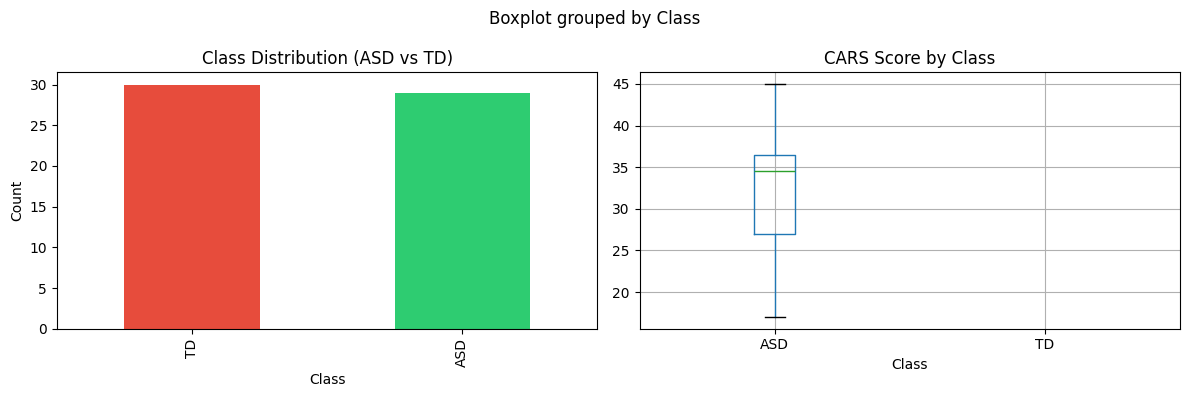


Full metadata with usable participants only:
Shape: (57, 5)
Class
TD     30
ASD    27
Name: count, dtype: int64


In [49]:
print("CARS Score missing values:", meta_df['CARS Score'].isnull().sum())
print(f"\nCARS Score stats:")
print(meta_df['CARS Score'].describe())

print(f"\nClass vs CARS Score:")
print(meta_df.groupby('Class')['CARS Score'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

meta_df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Class Distribution (ASD vs TD)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

meta_df.boxplot(column='CARS Score', by='Class', ax=axes[1])
axes[1].set_title('CARS Score by Class')

plt.tight_layout()
plt.savefig('eye_tracking_labels.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFull metadata with usable participants only:")
usable_meta = meta_df[meta_df['ParticipantID'].astype(str).isin(real_eye_participants)]
print(f"Shape: {usable_meta.shape}")
print(usable_meta['Class'].value_counts())

In [53]:
eye_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2252943 entries, 0 to 2252942
Data columns (total 60 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Unnamed: 0                    int64  
 1   RecordingTime [ms]            float64
 2   Time of Day [h:m:s:ms]        object 
 3   Trial                         object 
 4   Stimulus                      object 
 5   Export Start Trial Time [ms]  float64
 6   Export End Trial Time [ms]    float64
 7   Participant                   object 
 8   Color                         object 
 9   Tracking Ratio [%]            float64
 10  Category Group                object 
 11  Category Right                object 
 12  Category Left                 object 
 13  Index Right                   object 
 14  Index Left                    object 
 15  Pupil Diameter Right [mm]     object 
 16  Pupil Diameter Left [mm]      object 
 17  Point of Regard Right X [px]  object 
 18  Point of Regard Right 

In [52]:
# Key numeric columns we'll use for feature engineering
numeric_cols = [
    'Pupil Diameter Right [mm]', 'Pupil Diameter Left [mm]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]',
    'Gaze Vector Right X', 'Gaze Vector Right Y', 'Gaze Vector Right Z',
    'Gaze Vector Left X', 'Gaze Vector Left Y', 'Gaze Vector Left Z'
]

# Filter to real participants only (drop Unidentified)
eye_clean = eye_df[~eye_df['Participant'].astype(str).str.contains('Unidentified')].copy()
eye_clean['Participant'] = eye_clean['Participant'].astype(str)

print(f"Rows after dropping Unidentified: {len(eye_clean):,}")
print(f"Participants remaining: {eye_clean['Participant'].nunique()}")

# Stats per numeric column
print("\nNumeric feature summary:")
print(eye_clean[numeric_cols].describe().round(3))

Rows after dropping Unidentified: 1,351,157
Participants remaining: 57

Numeric feature summary:
       Pupil Diameter Right [mm] Pupil Diameter Left [mm]  \
count                     974399                   905519   
unique                     46683                    46563   
top                            0                        0   
freq                       34462                    28724   

       Point of Regard Right X [px] Point of Regard Right Y [px]  \
count                       1351157                      1351157   
unique                       768854                       752054   
top                               0                            0   
freq                         148102                       148356   

       Point of Regard Left X [px] Point of Regard Left Y [px]  \
count                      1282277                     1282277   
unique                      750014                      732606   
top                              0                        

In [54]:
# Columns to convert to numeric
cols_to_numeric = [
    'Pupil Diameter Right [mm]', 'Pupil Diameter Left [mm]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]',
    'Gaze Vector Right X', 'Gaze Vector Right Y', 'Gaze Vector Right Z',
    'Gaze Vector Left X', 'Gaze Vector Left Y', 'Gaze Vector Left Z',
    'Pupil Size Right X [px]', 'Pupil Size Right Y [px]',
    'Pupil Size Left X [px]', 'Pupil Size Left Y [px]',
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]',
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]',
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]',
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]',
    'Tracking Ratio [%]'
]

for col in cols_to_numeric:
    eye_clean[col] = pd.to_numeric(eye_clean[col], errors='coerce')

print("Dtypes after conversion:")
print(eye_clean[cols_to_numeric].dtypes)
print(f"\nMissing % after conversion (top 15):")
missing_after = (eye_clean[cols_to_numeric].isnull().sum() / len(eye_clean) * 100).round(1)
print(missing_after.sort_values(ascending=False).head(15))

Dtypes after conversion:
Pupil Diameter Right [mm]       float64
Pupil Diameter Left [mm]        float64
Point of Regard Right X [px]    float64
Point of Regard Right Y [px]    float64
Point of Regard Left X [px]     float64
Point of Regard Left Y [px]     float64
Gaze Vector Right X             float64
Gaze Vector Right Y             float64
Gaze Vector Right Z             float64
Gaze Vector Left X              float64
Gaze Vector Left Y              float64
Gaze Vector Left Z              float64
Pupil Size Right X [px]         float64
Pupil Size Right Y [px]         float64
Pupil Size Left X [px]          float64
Pupil Size Left Y [px]          float64
Eye Position Right X [mm]       float64
Eye Position Right Y [mm]       float64
Eye Position Right Z [mm]       float64
Eye Position Left X [mm]        float64
Eye Position Left Y [mm]        float64
Eye Position Left Z [mm]        float64
Pupil Position Right X [px]     float64
Pupil Position Right Y [px]     float64
Pupil Position 

## FEATURE ENGINEERING — Per-participant aggregation

In [55]:
def engineer_eye_features(df):
    features = {}
    
    # Gaze event counts from Category
    for side in ['Right', 'Left']:
        col = f'Category {side}'
        counts = df[col].value_counts()
        total = len(df)
        for event in ['Fixation', 'Saccade', 'Blink']:
            features[f'{side.lower()}_{event.lower()}_count'] = counts.get(event, 0)
            features[f'{side.lower()}_{event.lower()}_rate'] = counts.get(event, 0) / total
    
    # Tracking ratio
    features['tracking_ratio_mean'] = df['Tracking Ratio [%]'].mean()
    features['tracking_ratio_std'] = df['Tracking Ratio [%]'].std()
    
    # Pupil diameter
    for side in ['Right', 'Left']:
        col = f'Pupil Diameter {side} [mm]'
        valid = df[col].dropna()
        valid = valid[valid > 0]  # 0 values = tracker lost pupil
        features[f'pupil_{side.lower()}_mean'] = valid.mean() if len(valid) > 0 else np.nan
        features[f'pupil_{side.lower()}_std'] = valid.std() if len(valid) > 0 else np.nan
        features[f'pupil_{side.lower()}_missing_rate'] = df[col].isnull().sum() / len(df)
    
    # Gaze position (Point of Regard) 
    for side in ['Right', 'Left']:
        for axis in ['X', 'Y']:
            col = f'Point of Regard {side} {axis} [px]'
            valid = df[col].dropna()
            features[f'gaze_{side.lower()}_{axis.lower()}_mean'] = valid.mean()
            features[f'gaze_{side.lower()}_{axis.lower()}_std'] = valid.std()
    
    # Eye position (3D head position)
    for side in ['Right', 'Left']:
        for axis in ['X', 'Y', 'Z']:
            col = f'Eye Position {side} {axis} [mm]'
            valid = df[col].dropna()
            features[f'eye_pos_{side.lower()}_{axis.lower()}_mean'] = valid.mean() if len(valid) > 0 else np.nan
    
    # Tracking loss rate (gaze aversion signal)
    features['gaze_loss_rate_right'] = df['Point of Regard Right X [px]'].isnull().sum() / len(df)
    features['gaze_loss_rate_left'] = df['Point of Regard Left X [px]'].isnull().sum() / len(df)
    
    return features

# Apply per participant
participant_features = []
for pid, group in eye_clean.groupby('Participant'):
    feats = engineer_eye_features(group)
    feats['ParticipantID'] = str(pid)
    participant_features.append(feats)

eye_features_df = pd.DataFrame(participant_features)
print(f"Feature matrix shape: {eye_features_df.shape}")
print(f"\nFeature columns ({len(eye_features_df.columns)-1} features):")
print([c for c in eye_features_df.columns if c != 'ParticipantID'])

Feature matrix shape: (57, 37)

Feature columns (36 features):
['right_fixation_count', 'right_fixation_rate', 'right_saccade_count', 'right_saccade_rate', 'right_blink_count', 'right_blink_rate', 'left_fixation_count', 'left_fixation_rate', 'left_saccade_count', 'left_saccade_rate', 'left_blink_count', 'left_blink_rate', 'tracking_ratio_mean', 'tracking_ratio_std', 'pupil_right_mean', 'pupil_right_std', 'pupil_right_missing_rate', 'pupil_left_mean', 'pupil_left_std', 'pupil_left_missing_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_right_y_mean', 'gaze_right_y_std', 'gaze_left_x_mean', 'gaze_left_x_std', 'gaze_left_y_mean', 'gaze_left_y_std', 'eye_pos_right_x_mean', 'eye_pos_right_y_mean', 'eye_pos_right_z_mean', 'eye_pos_left_x_mean', 'eye_pos_left_y_mean', 'eye_pos_left_z_mean', 'gaze_loss_rate_right', 'gaze_loss_rate_left']


In [56]:
eye_features_df.head()

,right_fixation_count,right_fixation_rate,right_saccade_count,right_saccade_rate,right_blink_count,right_blink_rate,left_fixation_count,left_fixation_rate,left_saccade_count,left_saccade_rate,...,gaze_left_y_std,eye_pos_right_x_mean,eye_pos_right_y_mean,eye_pos_right_z_mean,eye_pos_left_x_mean,eye_pos_left_y_mean,eye_pos_left_z_mean,gaze_loss_rate_right,gaze_loss_rate_left,ParticipantID
0,6146,0.720431,914,0.107139,851,0.099754,6150,0.720900,921,0.107959,...,207.469071,-40.337453,-45.658127,647.771259,10.631844,-43.041760,649.179194,0.004220,0.004220,1
1,8026,0.864033,664,0.071482,423,0.045538,8032,0.864679,664,0.071482,...,167.753298,-53.040648,-97.163044,661.010382,0.985081,-87.687456,650.215914,0.003876,0.003876,10
2,9275,0.569123,1768,0.108486,4109,0.252132,5476,0.336013,974,0.059766,...,283.007871,-45.035700,-12.368732,519.108330,0.533176,-5.165325,461.558990,0.003191,0.382034,11
3,9026,0.682186,1957,0.147910,1819,0.137480,9038,0.683093,1931,0.145945,...,226.923709,-53.570918,-76.422091,580.736875,-7.854014,-76.856318,578.455563,0.004232,0.004232,13
4,9038,0.690609,1935,0.147857,1517,0.115917,9006,0.688164,1958,0.149614,...,222.094398,-18.185616,-5.787664,607.015540,30.878989,-8.253471,613.500088,0.004355,0.004355,14


In [57]:
# Merge with metadata labels
usable_meta['ParticipantID'] = usable_meta['ParticipantID'].astype(str)
eye_features_labeled = eye_features_df.merge(usable_meta[['ParticipantID', 'Class']], on='ParticipantID', how='inner')

print(f"Shape after merge: {eye_features_labeled.shape}")
print(f"\nClass distribution:")
print(eye_features_labeled['Class'].value_counts())

print(f"\nMissing values per feature:")
missing = eye_features_labeled.isnull().sum()
print(missing[missing > 0])

Shape after merge: (57, 38)

Class distribution:
Class
TD     30
ASD    27
Name: count, dtype: int64

Missing values per feature:
pupil_left_mean        1
pupil_left_std         1
gaze_left_x_mean       1
gaze_left_x_std        1
gaze_left_y_mean       1
gaze_left_y_std        1
eye_pos_left_x_mean    1
eye_pos_left_y_mean    1
eye_pos_left_z_mean    1
dtype: int64


In [59]:
eye_features_labeled.tail()

,right_fixation_count,right_fixation_rate,right_saccade_count,right_saccade_rate,right_blink_count,right_blink_rate,left_fixation_count,left_fixation_rate,left_saccade_count,left_saccade_rate,...,eye_pos_right_x_mean,eye_pos_right_y_mean,eye_pos_right_z_mean,eye_pos_left_x_mean,eye_pos_left_y_mean,eye_pos_left_z_mean,gaze_loss_rate_right,gaze_loss_rate_left,ParticipantID,Class
52,32793,0.727408,2719,0.060312,8718,0.193381,28407,0.630118,2028,0.044985,...,-1.472153,-25.098503,409.742003,-44.484995,-23.849189,400.220397,0.001641,0.131228,59,TD
53,6408,0.768437,741,0.088860,601,0.072071,6414,0.769157,744,0.089219,...,-31.739507,-70.269399,590.932215,8.664223,-66.166174,593.484308,0.004317,0.004317,6,ASD
54,2390,0.386294,745,0.120414,2370,0.383061,2387,0.385809,764,0.123485,...,-11.280405,-36.088178,358.607242,18.797531,-38.018231,369.438090,0.005819,0.005819,7,ASD
55,2043,0.326097,826,0.131844,2248,0.358819,2042,0.325938,817,0.130407,...,-49.598870,-36.003314,427.338250,-9.971866,-42.554111,421.483001,0.005746,0.005746,8,ASD
56,1246,0.162706,1109,0.144816,3741,0.488509,1236,0.161400,1148,0.149909,...,14.404305,-83.664434,554.559752,53.961680,-84.448438,550.792227,0.004701,0.004701,9,ASD


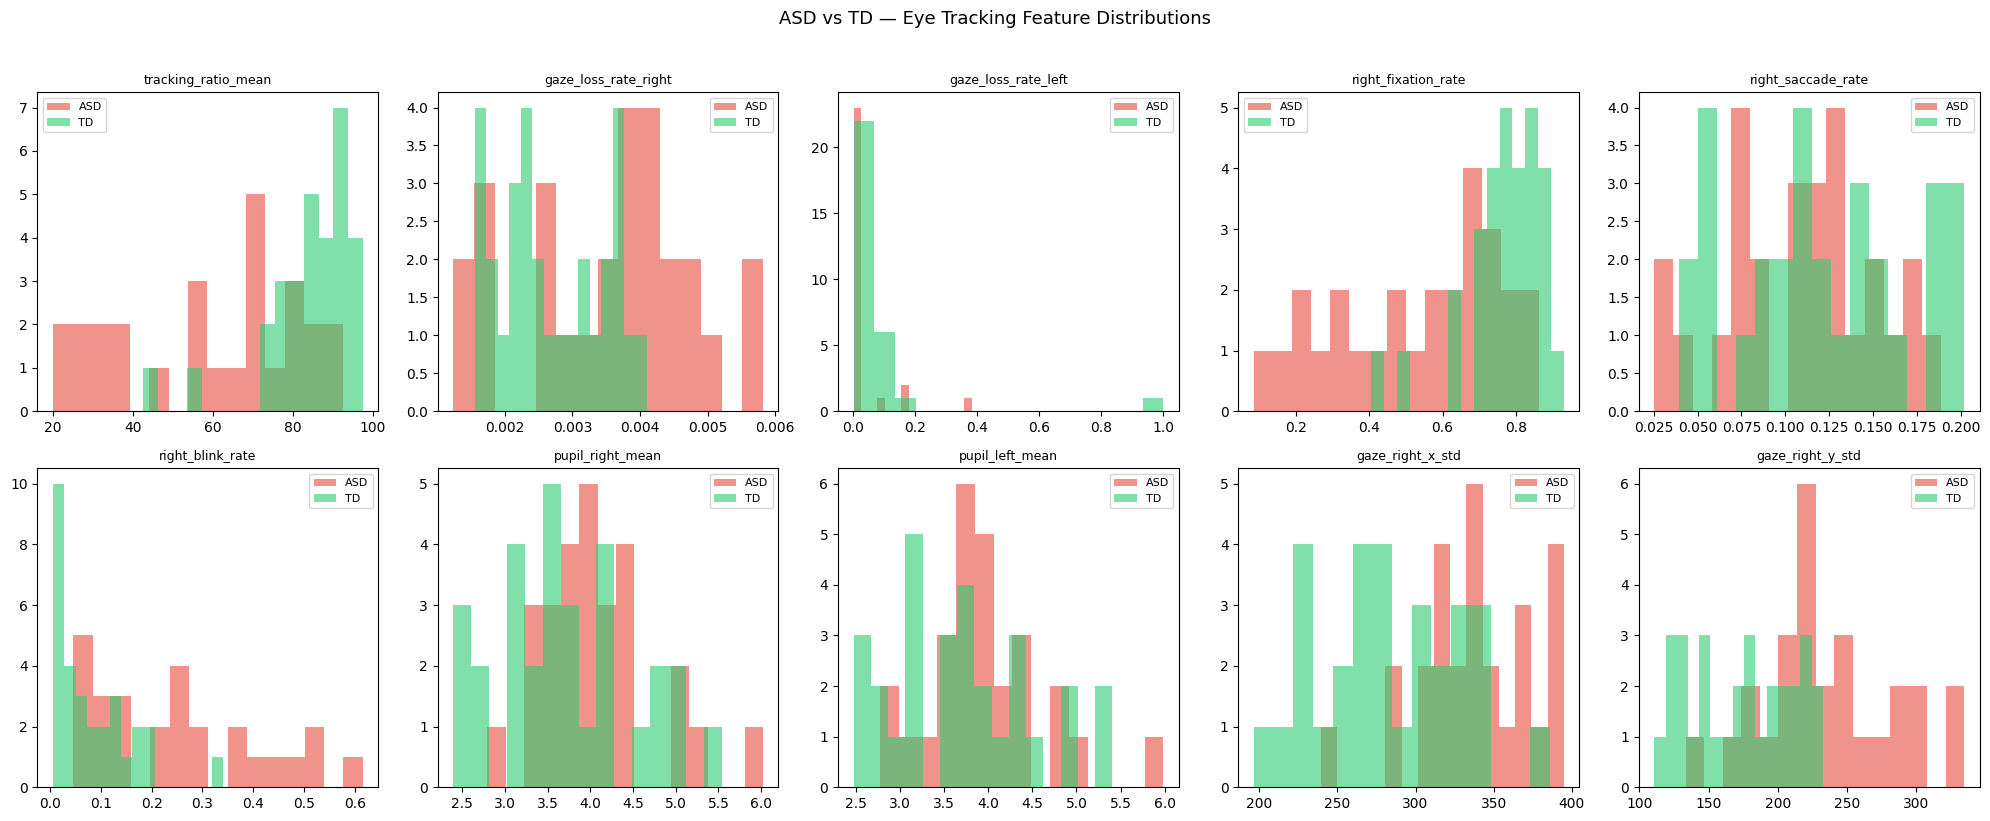

In [60]:
# Compare ASD vs TD distributions for most informative features
key_features = [
    'tracking_ratio_mean', 'gaze_loss_rate_right', 'gaze_loss_rate_left',
    'right_fixation_rate', 'right_saccade_rate', 'right_blink_rate',
    'pupil_right_mean', 'pupil_left_mean',
    'gaze_right_x_std', 'gaze_right_y_std'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    asd_vals = eye_features_labeled[eye_features_labeled['Class']=='ASD'][feat].dropna()
    td_vals = eye_features_labeled[eye_features_labeled['Class']=='TD'][feat].dropna()
    
    axes[i].hist(asd_vals, alpha=0.6, color='#e74c3c', label='ASD', bins=15)
    axes[i].hist(td_vals, alpha=0.6, color='#2ecc71', label='TD', bins=15)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('ASD vs TD — Eye Tracking Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eye_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# Save to your own Google Drive root instead
eye_features_labeled.to_csv('/content/drive/MyDrive/eye_tracking_features.csv', index=False)
print("Eye tracking features saved to MyDrive root.")

Eye tracking features saved to MyDrive root.


### Facial Image Dataset
- **Total images:** 3,398 (~416×416px, YOLO format)
- **Classes:** 0=autistic_face, 1=autism → merged to ASD; 2=no_autism → TD
- **Split:** train/val/test
- **Issue:** Class imbalance in val/test (~1:2 ratio) → will use weighted loss during training
- **Saved in:** `Dataset/autism_dataset/images/`

### Eye-Tracking Dataset
- **Participants:** 57 usable (out of 59 — participants 12 & 16 excluded, no recordings)
- **Class distribution:** 27 ASD, 30 TD — near balanced ✅
- **Raw data:** 25 CSVs in `Eye-tracking Output/`, 1.3M rows after cleaning
- **Metadata:** 59 rows, columns: ParticipantID, Gender, Age, Class, CARS Score
- **CARS Score:** Only available for ASD participants — not usable as feature (label leakage)
- **Engineered features:** 36 per-participant aggregated features
- **Feature matrix saved:** `/content/drive/MyDrive/eye_tracking_features.csv`

### Key Findings
| Feature | Observation |
|---|---|
| `gaze_loss_rate_left` | Strongest ASD vs TD separator |
| `tracking_ratio_mean` | ASD children tracked less consistently |
| `right_blink_rate` | ASD children concentrated near 0, long tail |
| `pupil_right/left_mean` | High overlap — weak discriminator alone |

### Known Issues
| Issue | Resolution |
|---|---|
| Participants 12 & 16 missing eye data | Excluded from eye-tracking branch |
| 1 participant missing all left eye features | Impute with median in preprocessing |
| Facial class imbalance in val/test | Weighted loss function |
